In [915]:
import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt 
%matplotlib inline

In [916]:
words=open('names.txt','r').read().splitlines()

In [917]:
words[:8]



['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [918]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}        
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [919]:
block_size = 3
x, y = [], []
for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        x.append(context)
        y.append(ix)
        # print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix]
x = torch.tensor(x)
y = torch.tensor(y)
print(x.shape, y.shape)

torch.Size([228146, 3]) torch.Size([228146])


In [920]:
c= torch.randn((27,2))

In [921]:
c[0]

tensor([-1.0093,  0.0140])

In [922]:
embed=c[x]

In [923]:
embed.shape

torch.Size([228146, 3, 2])

In [924]:
w1=torch.randn((6,100))
b=torch.randn(100)

In [925]:
torch.unbind(embed,1)

(tensor([[-1.0093,  0.0140],
         [-1.0093,  0.0140],
         [-1.0093,  0.0140],
         ...,
         [ 1.4846, -0.6339],
         [ 1.4846, -0.6339],
         [-0.6629, -0.2774]]),
 tensor([[-1.0093,  0.0140],
         [-1.0093,  0.0140],
         [ 0.2522,  1.1478],
         ...,
         [ 1.4846, -0.6339],
         [-0.6629, -0.2774],
         [ 1.4846, -0.6339]]),
 tensor([[-1.0093,  0.0140],
         [ 0.2522,  1.1478],
         [-0.3088, -0.2412],
         ...,
         [-0.6629, -0.2774],
         [ 1.4846, -0.6339],
         [ 0.1528, -0.9680]]))

In [926]:
embed.view(-1,6).shape

torch.Size([228146, 6])

In [927]:
embed.view(-1,6) @ w1 + b

tensor([[ 0.5779,  0.7001, -0.1573,  ...,  1.6971,  1.4110, -1.2086],
        [ 0.6905,  1.1574, -0.4631,  ...,  2.6310, -0.1167, -1.1856],
        [-0.1671, -0.2968, -2.6312,  ..., -0.3729,  1.8883, -0.6636],
        ...,
        [-4.2163, -2.1860, -0.3620,  ...,  1.5058, -0.1062, -4.7004],
        [-3.9677,  0.0301,  0.9355,  ...,  3.9980, -2.6356, -2.8583],
        [-3.9983, -0.1093, -1.4523,  ..., -0.5087,  3.2928, -4.4097]])

In [928]:
h=embed.view(-1,6) @ w1 + b

In [929]:
h=torch.tanh(h)

In [930]:
w2=torch.randn((100,27))
b2=torch.randn(27)
logits = h @ w2 + b2

In [931]:
logits.shape

torch.Size([228146, 27])

In [932]:
counts=logits.exp()

In [933]:
p = counts / counts.sum(1, keepdim=True)

In [934]:
p.shape

torch.Size([228146, 27])

In [935]:
loss=-p[torch.arange(len(y)),y].log().mean()

In [936]:
# ------------ now made respectable :) ---------------

In [937]:
g=torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [938]:
sum(p.nelement() for p in parameters) 

3481

In [939]:
embed.shape

torch.Size([228146, 3, 2])

In [940]:
for p in parameters:
    p.requires_grad = True  

In [941]:
emb=C[x]
h=emb.view(-1,6) @ W1 + b1
h=torch.tanh(h)
logits = h @ W2 + b2
counts=logits.exp()
p = counts / counts.sum(1, keepdim=True)
loss=-p[torch.arange(len(y)),y].log().mean()    
loss

tensor(19.5052, grad_fn=<NegBackward0>)

In [942]:
F.cross_entropy(logits, y)

tensor(19.5052, grad_fn=<NllLossBackward0>)

In [943]:
C[x].shape

torch.Size([228146, 3, 2])

In [944]:
lre=torch.linspace(-3,0,1000)
lrs=10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [945]:
lri=[]
lossi=[]
for _ in range(1000):
    #minibatch gradient descent
    ix=torch.randint(0, len(x), (32,))
    emb=C[x[ix]]
    h=emb.view(-1,6) @ W1 + b1
    h=torch.tanh(h)
    logits = h @ W2 + b2
    loss=F.cross_entropy(logits, y[ix])
    for p in parameters:
        p.grad = None
    loss.backward()
    lr=lrs[_]
    # lr=0.01
    for p in parameters:
        p.data += -lr * p.grad 
    print(loss.item())
    lri.append(lre[_].item())
    lossi.append(loss.item())
  

21.433082580566406
18.438451766967773
19.87318229675293
18.86762046813965
18.152212142944336
19.807558059692383
19.055959701538086
17.666728973388672
20.854455947875977
18.41973304748535
17.296405792236328
19.146228790283203
20.85685920715332
19.73488998413086
19.84000587463379
18.661863327026367
16.643150329589844
19.157154083251953
17.062257766723633
19.677509307861328
20.584781646728516
18.786197662353516
17.08574867248535
20.53717041015625
22.75335693359375
16.679611206054688
19.6364688873291
20.901010513305664
18.352928161621094
14.920717239379883
17.610342025756836
18.829851150512695
18.952472686767578
17.271953582763672
17.039222717285156
16.823272705078125
18.055875778198242
15.049644470214844
15.221738815307617
18.34436798095703
15.366262435913086
19.746658325195312
18.12265968322754
15.396754264831543
17.43256950378418
18.268573760986328
21.089914321899414
15.323535919189453
15.989435195922852
15.622206687927246
17.336801528930664
18.786041259765625
18.310441970825195
18.3273

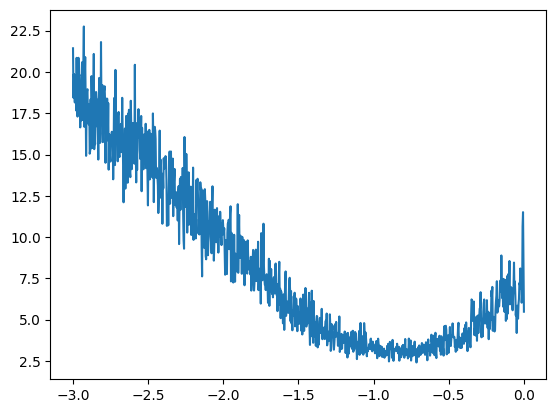

In [946]:
plt.plot(lri, lossi)

In [947]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [948]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [949]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [950]:
sum(p.nelement() for p in parameters)

10281

In [951]:
for p in parameters:
  p.requires_grad = True

In [952]:
Xtr.shape

torch.Size([182625, 3])

In [957]:
lri=[]
lossi=[]
stepi=[]
for i in range(30000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  # print(ix.shape)
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 2)
  # print(emb.shape)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 300)
  # print(h.shape)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad
  if i % 1000 == 0:
     print(f'Iteration {i}: Loss = {loss.item():.4f}')
  lri.append(lr)
  lossi.append(loss.item())
  stepi.append(i)


Iteration 0: Loss = 2.2998
Iteration 1000: Loss = 2.4430
Iteration 2000: Loss = 2.9563
Iteration 3000: Loss = 3.0093
Iteration 4000: Loss = 2.2274
Iteration 5000: Loss = 2.2969
Iteration 6000: Loss = 2.7954
Iteration 7000: Loss = 2.7701
Iteration 8000: Loss = 2.3998
Iteration 9000: Loss = 2.2973
Iteration 10000: Loss = 2.6269
Iteration 11000: Loss = 2.5972
Iteration 12000: Loss = 2.2624
Iteration 13000: Loss = 2.5023
Iteration 14000: Loss = 2.3251
Iteration 15000: Loss = 2.4008
Iteration 16000: Loss = 2.5554
Iteration 17000: Loss = 2.6816
Iteration 18000: Loss = 2.4386
Iteration 19000: Loss = 2.2702
Iteration 20000: Loss = 2.1864
Iteration 21000: Loss = 2.4604
Iteration 22000: Loss = 2.3298
Iteration 23000: Loss = 2.4378
Iteration 24000: Loss = 2.5680
Iteration 25000: Loss = 2.3689
Iteration 26000: Loss = 2.4550
Iteration 27000: Loss = 2.2454
Iteration 28000: Loss = 2.7564
Iteration 29000: Loss = 2.3748


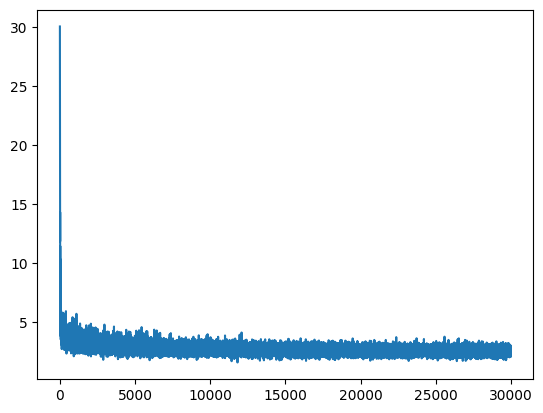

In [954]:
plt.plot(stepi, lossi)

In [958]:
emb=C[Xtr]
print(emb.shape)
h=emb.view(-1, 6) @ W1 + b1
h=torch.tanh(h)
logits = h @ W2 + b2  
print(logits.shape)  
print(Ytr.shape)  
loss=F.cross_entropy(logits, Ytr)
loss

torch.Size([182625, 3, 2])
torch.Size([182625, 27])
torch.Size([182625])


tensor(2.3990, grad_fn=<NllLossBackward0>)

In [959]:
emb=C[Xdev]
h=emb.view(-1,6) @ W1 + b1
h=torch.tanh(h)
logits = h @ W2 + b2    
loss=F.cross_entropy(logits, Ydev)
loss

tensor(2.4007, grad_fn=<NllLossBackward0>)

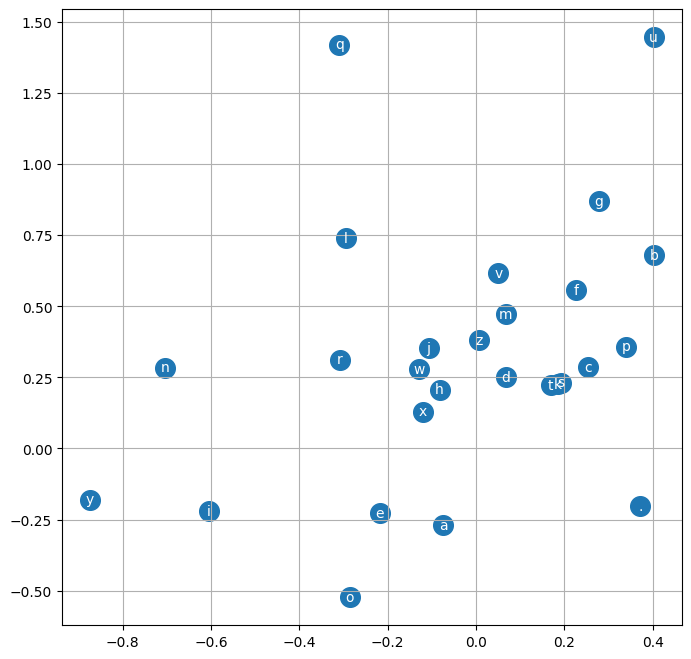

In [960]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [961]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carlai.
allyn.
kallin.
lirea.
lannanden.
jaronte.
dperric.
laqui.
nelonia.
chaiiv.
kaleig.
dham.
joi.
den.
juzanlin.
alia.
bicon.
tar.
diaryn.
kal.
